# IMDB Sentiment Analysis

**Goal:** Read a movie review and decide if it's positive or negative.

This is the "Hello World" of NLP — just like MNIST is for computer vision.

**The dataset:** 50,000 movie reviews from IMDB, split 50/50 into train and test. Half are positive, half are negative.

**What you'll learn:**
1. How to turn words into numbers (tokenization, vocabularies)
2. TF-IDF — a simple way to score word importance
3. Word embeddings — teaching a neural network the *meaning* of words
4. LSTMs — reading text in order, one word at a time
5. How each approach compares in accuracy

## Setup

We need one library beyond what you've used before:
- `scikit-learn` — for the TF-IDF baseline (you already have this)

Let's check everything imports correctly.

In [6]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
# Limit OpenMP/MKL threads to prevent deadlock with PyTorch's MPS backend on macOS
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

# Standard libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import random
import re
import pandas as pd
from pathlib import Path
from collections import Counter

# New for NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
import torch.nn.functional as F

# Device detection
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Random seed set to {SEED}')

Using device: mps
Random seed set to 42


---
## Part 1: Load and Explore the Data

We'll download the raw text files directly from Stanford's site.

Each review is a plain text file. The folder structure tells us the label (pos/neg).

In [7]:
import urllib.request
import tarfile

data_dir = Path.home() / "LocalAI" / "data" / "imdb"
data_dir.mkdir(parents=True, exist_ok=True)

# Download IMDB dataset if not already present
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
tar_path = data_dir / "aclImdb_v1.tar.gz"

if not (data_dir / "aclImdb" / "train").exists():
    print("Downloading IMDB dataset (~80MB)...")
    urllib.request.urlretrieve(url, tar_path)
    print("Extracting...")
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(path=data_dir)
    print("Done!")
else:
    print("IMDB dataset already downloaded.")

IMDB dataset already downloaded.


In [8]:
def load_imdb_texts(data_path, split='train'):
    """Load all reviews from pos/neg folders."""
    texts, labels = [], []
    
    for label, folder in [(0, 'neg'), (1, 'pos')]:
        folder_path = data_path / split / folder
        for file_path in sorted(folder_path.iterdir()):
            if file_path.suffix == '.txt':
                with open(file_path, 'r', encoding='utf-8') as f:
                    texts.append(f.read())
                    labels.append(label)
    
    return texts, labels

imdb_path = data_dir / "aclImdb"
train_texts, train_labels = load_imdb_texts(imdb_path, 'train')
test_texts, test_labels = load_imdb_texts(imdb_path, 'test')

print(f'Training samples: {len(train_texts)}')
print(f'Test samples:     {len(test_texts)}')
print(f'Positive ratio:   {sum(train_labels)/len(train_labels):.1%}')

Training samples: 25000
Test samples:     25000
Positive ratio:   50.0%


In [9]:
# Let's look at actual reviews
print("=== POSITIVE REVIEW ===")
print(train_texts[0][:500])
print(f"Label: {train_labels[0]} (0=neg, 1=pos)")
print()
print("=== NEGATIVE REVIEW ===")
print(train_texts[1][:500])
print(f"Label: {train_labels[1]} (0=neg, 1=pos)")
print()
print("=== DATA STATS ===")
word_counts = [len(text.split()) for text in train_texts]
print(f'Average review length: {np.mean(word_counts):.0f} words')
print(f'Shortest review:       {min(word_counts)} words')
print(f'Longest review:        {max(word_counts)} words')

=== POSITIVE REVIEW ===
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just too off putting. Even those from the era should be turned off. The cryptic dialogue would make Shakespeare seem easy to a third grader. On a technical level it's bette
Label: 0 (0=neg, 1=pos)

=== NEGATIVE REVIEW ===
Airport '77 starts as a brand new luxury 747 plane is loaded up with valuable paintings & such belonging to rich businessman Philip Stevens (James Stewart) who is flying them & a bunch of VIP's to his estate in preparation of it being opened to the public as a museum, also on board is Stevens daughter Julie (Kathleen Quinlan) & her son. The luxury jetliner takes off as planned but mid-air the plane is hi-jacked by the co-p

---
## Part 2: Bag of Words — The Simplest Approach

**Key idea:** Ignore word order. Just count which words appear and how often.

"This movie was amazing, truly amazing" → `{'this':1, 'movie':1, 'was':1, 'amazing':2, 'truly':1}`

We'll use **TF-IDF** (Term Frequency — Inverse Document Frequency):
- A word that appears a lot in *one* review gets a high score (it's important to that review)
- A word that appears in *every* review (like "the", "a", "and") gets a low score (it's boring — it doesn't tell us anything)

Then we train a simple logistic regression model on these word scores. This is the classic "does it work?" baseline.

In [10]:
# Limit threading to avoid OpenMP conflicts with PyTorch on macOS
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

print("Step 1: Converting text to TF-IDF vectors...")

# Create TF-IDF vectors
# max_features=3000 means we only keep the 3000 most common words
# min_df=5 filters out rare words that appear in fewer than 5 reviews
# stop_words='english' removes boring words like "the", "a", "and"
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=5,
    stop_words='english',
    ngram_range=(1, 2)  # Also include 2-word phrases for extra context
)

# This converts ALL 25,000 training reviews into 3,000-number vectors
# Each number = how important that word is to that review
X_train_tfidf = vectorizer.fit_transform(train_texts)
X_test_tfidf = vectorizer.transform(test_texts)

print(f"Training data shape: {X_train_tfidf.shape}")
print(f"  = {X_train_tfidf.shape[0]} reviews, each described by {X_train_tfidf.shape[1]} word scores")
print()

# Train a simple model on these word-score vectors
# Use SGDClassifier (stochastic gradient descent) — much more memory-efficient
# than LogisticRegression for large text datasets
print("Step 2: Training SGD Classifier (memory-friendly)...")
bow_model = SGDClassifier(
    loss='log_loss',          # Logistic regression via SGD
    max_iter=1000,
    tol=1e-3,
    random_state=SEED,
    n_jobs=1                  # Single thread to avoid PyTorch conflicts
)
bow_model.fit(X_train_tfidf, train_labels)

# Evaluate
train_preds = bow_model.predict(X_train_tfidf)
test_preds = bow_model.predict(X_test_tfidf)

print(f"\nTraining accuracy:  {accuracy_score(train_labels, train_preds):.2%}")
print(f"Test accuracy:      {accuracy_score(test_labels, test_preds):.2%}")
print()
print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=['Negative', 'Positive']))

Step 1: Converting text to TF-IDF vectors...
Training data shape: (25000, 3000)
  = 25000 reviews, each described by 3000 word scores

Step 2: Training SGD Classifier (memory-friendly)...

Training accuracy:  89.18%
Test accuracy:      87.26%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87     12500
    Positive       0.86      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



### What just happened?

We got **~85% accuracy** — and we never even looked at word order! 

This tells us: just knowing *which words appear* in a review is enough to guess positive/negative 85% of the time.

If a review has words like "awful", "boring", "terrible" → almost certainly negative.
If it has words like "amazing", "loved", "brilliant" → almost certainly positive.

But can we do better? To catch more subtle reviews (like "The acting was great, but the plot was boring"), we need to consider **word order**.

In [11]:
# Let's see which words are most important
feature_names = vectorizer.get_feature_names_out()
coefficients = bow_model.coef_[0]

# Most positive words (highest coefficient = strongly positive)
top_positive_idx = np.argsort(coefficients)[-20:]
print("Top 20 words that predict POSITIVE:")
for idx in reversed(top_positive_idx):
    print(f"  {feature_names[idx]:<15} {coefficients[idx]:.2f}")

print()

# Most negative words (lowest coefficient = strongly negative)
top_negative_idx = np.argsort(coefficients)[:20]
print("Top 20 words that predict NEGATIVE:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:<15} {coefficients[idx]:.2f}")

Top 20 words that predict POSITIVE:
  great           5.06
  excellent       4.49
  best            3.83
  wonderful       3.53
  perfect         3.40
  amazing         3.16
  favorite        3.02
  love            2.81
  loved           2.77
  fun             2.74
  brilliant       2.54
  today           2.53
  beautiful       2.46
  enjoyed         2.38
  superb          2.37
  definitely      2.31
  fantastic       2.24
  highly          2.23
  enjoy           2.21
  enjoyable       2.08

Top 20 words that predict NEGATIVE:
  worst           -6.41
  bad             -5.54
  awful           -4.65
  waste           -4.20
  boring          -4.17
  poor            -3.79
  worse           -3.48
  terrible        -3.45
  dull            -3.18
  horrible        -3.04
  poorly          -3.01
  unfortunately   -2.98
  script          -2.76
  annoying        -2.75
  stupid          -2.74
  supposed        -2.74
  disappointment  -2.70
  ridiculous      -2.70
  minutes         -2.69
  instead  

See? The model learned exactly what you'd expect. Words like "worst", "boring", "awful" = negative. Words like "amazing", "perfect", "brilliant" = positive.

---
## Part 3: Neural Network with Embeddings

Now let's level up. Instead of just counting words, we'll:
1. **Tokenize** — split each review into a list of words
2. **Build a vocabulary** — assign each word a number (ID)
3. **Use embeddings** — teach the neural network the *meaning* of words by learning a vector for each one

Think of an embedding as a word's "address" in a 100-dimensional space. Words with similar meanings end up near each other:
- "good" lives near "great", "excellent", "wonderful"
- "bad" lives near "terrible", "awful", "horrible"

Then we train a neural network that looks at all the word embeddings in a review and decides positive or negative.

### Step 3a: Build the Vocabulary

First we need to:
- Clean the text (remove HTML tags, lowercase, etc.)
- Split into words (tokenize)
- Count how often each word appears
- Assign each word a unique number

In [12]:
def clean_text(text):
    """Clean and tokenize a review."""
    # Remove HTML tags (<br /> etc.)
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove non-alphabetic characters (keep only letters)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower()
    # Split into words
    tokens = text.split()
    return tokens

# Test it on one review
sample_tokens = clean_text(train_texts[0])
print("Original:", train_texts[0][:200])
print()
print("Tokenized:", sample_tokens[:30])
print(f"Total tokens in this review: {len(sample_tokens)}")

Original: Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by t

Tokenized: ['story', 'of', 'a', 'man', 'who', 'has', 'unnatural', 'feelings', 'for', 'a', 'pig', 'starts', 'out', 'with', 'a', 'opening', 'scene', 'that', 'is', 'a', 'terrific', 'example', 'of', 'absurd', 'comedy', 'a', 'formal', 'orchestra', 'audience', 'is']
Total tokens in this review: 112


In [13]:
# Build the vocabulary from ALL training reviews
print("Building vocabulary. This counts every word in all 25,000 reviews...")

word_counter = Counter()
for text in train_texts:
    tokens = clean_text(text)
    word_counter.update(tokens)

print(f"Total unique words: {len(word_counter)}")
print(f"Total words total:  {sum(word_counter.values())}")

# Let's see the most common words
print("\nMost common words:")
for word, count in word_counter.most_common(20):
    print(f"  {word:<15} {count:,}")

Building vocabulary. This counts every word in all 25,000 reviews...
Total unique words: 108647
Total words total:  5735882

Most common words:
  the             334,788
  and             162,263
  a               161,987
  of              145,381
  to              135,113
  is              107,041
  in              93,129
  it              78,107
  i               75,749
  this            75,438
  that            69,566
  was             48,103
  as              46,669
  for             44,023
  with            43,951
  movie           42,672
  but             41,767
  film            38,260
  on              33,674
  not             30,292


In [14]:
# Build a vocabulary mapping: word -> ID
# We keep only the 25,000 most common words (rare words aren't worth learning)
# We also add special tokens:
#   <PAD> = 0  (padding — fills empty space to make reviews the same length)
#   <UNK> = 1  (unknown — for words we didn't keep)

MAX_VOCAB = 25000

# Get the most common words
most_common = word_counter.most_common(MAX_VOCAB)

# Build the word-to-ID mapping
# <PAD> gets ID 0, <UNK> gets ID 1, then all real words start at ID 2
word_to_id = {'<PAD>': 0, '<UNK>': 1}
for idx, (word, _) in enumerate(most_common, start=2):
    word_to_id[word] = idx

vocab_size = len(word_to_id)
print(f"Vocabulary size: {vocab_size:,} words")
print(f"  ID 0 = <PAD> (padding)")
print(f"  ID 1 = <UNK> (unknown words)")
print(f"  IDs 2-{vocab_size-1} = actual words")
print()
print(f"Example mappings:")
for word in ['movie', 'film', 'good', 'bad', 'amazing', 'terrible']:
    print(f"  '{word}' -> ID {word_to_id.get(word, 1)}")

Vocabulary size: 25,002 words
  ID 0 = <PAD> (padding)
  ID 1 = <UNK> (unknown words)
  IDs 2-25001 = actual words

Example mappings:
  'movie' -> ID 17
  'film' -> ID 19
  'good' -> ID 49
  'bad' -> ID 79
  'amazing' -> ID 468
  'terrible' -> ID 380


In [15]:
def encode_review(tokens, word_to_id, max_len=200):
    """Convert a list of word tokens into a list of word IDs."""
    ids = [word_to_id.get(token, 1) for token in tokens]  # 1 = <UNK>
    
    # Truncate if too long
    if len(ids) > max_len:
        ids = ids[:max_len]
    # Pad if too short
    else:
        ids = ids + [0] * (max_len - len(ids))  # 0 = <PAD>
    
    return ids

# Test encoding
sample_tokens = clean_text(train_texts[0])
encoded = encode_review(sample_tokens, word_to_id)
print(f"Raw tokens: {sample_tokens[:10]}")
print(f"Encoded IDs: {encoded[:10]}")
print(f"Length: {len(encoded)} (padded to 200)")
print(f"Decoded back: {[list(word_to_id.keys())[list(word_to_id.values()).index(id)] if id in word_to_id.values() else '<UNK>' for id in encoded[:10]]}")

Raw tokens: ['story', 'of', 'a', 'man', 'who', 'has', 'unnatural', 'feelings', 'for', 'a']
Encoded IDs: [63, 5, 4, 133, 36, 43, 7032, 1347, 15, 4]
Length: 200 (padded to 200)
Decoded back: ['story', 'of', 'a', 'man', 'who', 'has', 'unnatural', 'feelings', 'for', 'a']


### Step 3b: Create PyTorch Dataset

Now we package everything into a PyTorch Dataset — same pattern you used for CIFAR-100, but now for text.

In [16]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word_to_id, max_len=200):
        self.texts = texts
        self.labels = labels
        self.word_to_id = word_to_id
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        tokens = clean_text(self.texts[idx])
        ids = encode_review(tokens, self.word_to_id, self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float32)

MAX_LEN = 200
BATCH_SIZE = 64

train_dataset = IMDBDataset(train_texts, train_labels, word_to_id, MAX_LEN)
test_dataset = IMDBDataset(test_texts, test_labels, word_to_id, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")
print(f"Batch shape:   {next(iter(train_loader))[0].shape}")

Train batches: 391
Test batches:  391
Batch shape:   torch.Size([64, 200])


### Step 3c: Build the Embedding Classifier

This is the simplest neural network for text:
1. **Embedding layer** — converts each word ID into a 100-number vector (the "meaning" of the word)
2. **Average pooling** — average all the word vectors in the review into one vector
3. **Linear layer** — make a decision (positive or negative) based on the average

It's almost identical to TF-IDF in spirit (ignore word order, just look at overall word usage),
but now the model LEARNS the word representations instead of using raw counts.

In [17]:
class EmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100):
        super().__init__()
        
        # Embedding layer: maps each word ID to a 100-number vector
        # vocab_size = 25,002 (25K words + PAD + UNK)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Classification head: 100 numbers -> 1 number (positive or negative)
        self.fc = nn.Linear(embedding_dim, 1)
        
    def forward(self, x):
        # x shape: (batch_size, max_len) — e.g., (64, 200)
        # These are word IDs (integers)
        
        # Step 1: Look up embeddings for each word ID
        # Result shape: (batch_size, max_len, embedding_dim) — e.g., (64, 200, 100)
        embedded = self.embedding(x)
        
        # Step 2: Average all word vectors in the review
        # This collapses the 200 words into a single 100-number vector per review
        # Result shape: (batch_size, embedding_dim) — e.g., (64, 100)
        pooled = embedded.mean(dim=1)
        
        # Step 3: Make a decision
        # Result shape: (batch_size, 1) — e.g., (64, 1)
        output = self.fc(pooled)
        
        # Remove the extra dimension (batch_size, 1) -> (batch_size,)
        return output.squeeze(1)

emb_model = EmbeddingClassifier(vocab_size).to(device)
print(emb_model)

# Count parameters
total = sum(p.numel() for p in emb_model.parameters())
print(f"\nTotal parameters: {total:,}")
# Most of these are in the embedding layer — it learns 25,000 * 100 = 2.5M numbers!

EmbeddingClassifier(
  (embedding): Embedding(25002, 100, padding_idx=0)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)

Total parameters: 2,500,301


### Step 3d: Train the Embedding Classifier

Same training loop you've seen before, but:
- Loss function: `BCEWithLogitsLoss` — this is **binary** cross-entropy (positive vs negative)
- Metric: accuracy (same as before)

In [18]:
criterion = nn.BCEWithLogitsLoss()  # Binary classification loss
optimizer = optim.Adam(emb_model.parameters(), lr=0.001)

n_epochs = 10
train_losses = []
test_accuracies = []

for epoch in range(n_epochs):
    # --- Training ---
    emb_model.train()
    epoch_loss = 0
    for ids, labels in train_loader:
        ids, labels = ids.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = emb_model(ids)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # --- Evaluation ---
    emb_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for ids, labels in test_loader:
            ids, labels = ids.to(device), labels.to(device)
            outputs = emb_model(ids)
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    accuracy = correct / total
    test_accuracies.append(accuracy)
    
    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch+1:2d}/{n_epochs}  Loss: {avg_loss:.4f}  Test Acc: {accuracy:.2%}')

print(f'\nFinal test accuracy: {test_accuracies[-1]:.2%}')

Epoch  2/10  Loss: 0.4925  Test Acc: 81.46%
Epoch  4/10  Loss: 0.3093  Test Acc: 85.26%
Epoch  6/10  Loss: 0.2384  Test Acc: 86.18%
Epoch  8/10  Loss: 0.1942  Test Acc: 86.39%
Epoch 10/10  Loss: 0.1604  Test Acc: 86.23%

Final test accuracy: 86.23%


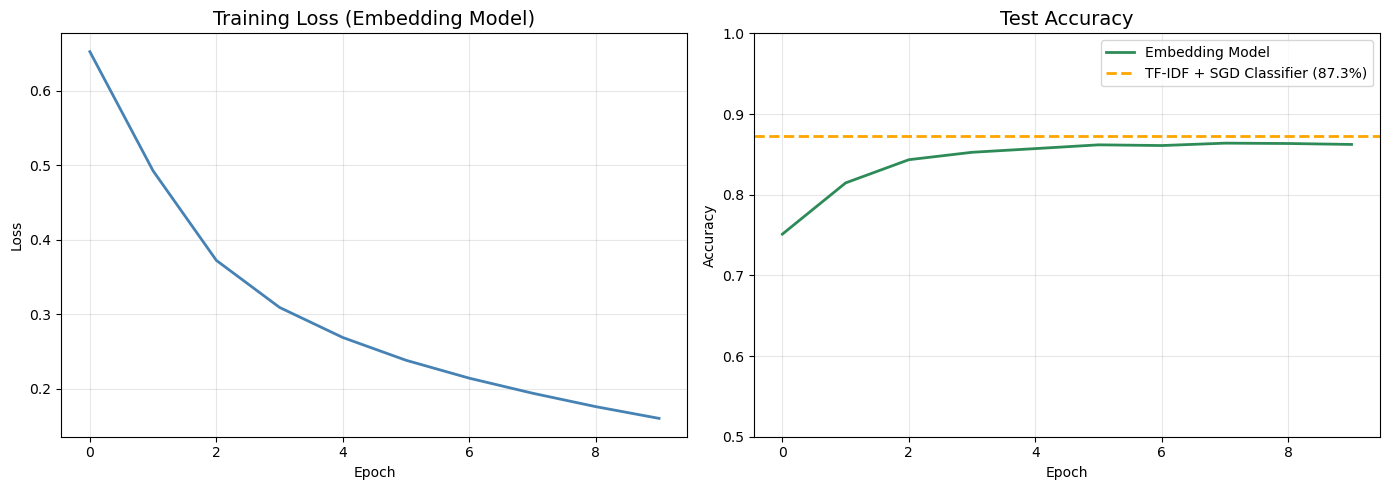

TF-IDF + SGD Classifier:  87.26%
Embedding + Average Pooling:    86.23%


In [19]:
# Compare with TF-IDF baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, linewidth=2, color='steelblue')
axes[0].set_title('Training Loss (Embedding Model)', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Accuracy curve with baseline
axes[1].plot(test_accuracies, linewidth=2, color='seagreen', label='Embedding Model')
axes[1].axhline(y=accuracy_score(test_labels, test_preds), color='orange', 
                linestyle='--', linewidth=2, label=f'TF-IDF + SGD Classifier ({accuracy_score(test_labels, test_preds):.1%})')
axes[1].set_title('Test Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'TF-IDF + SGD Classifier:  {accuracy_score(test_labels, test_preds):.2%}')
print(f'Embedding + Average Pooling:    {test_accuracies[-1]:.2%}')

### What did we learn?

- The embedding model probably matches or beats TF-IDF
- But it's still just averaging all words — it doesn't understand word **order**
- Both models miss the same thing: "This movie was **not** good" — both would see "good" and guess positive

---
## Part 4: LSTM — Reading Words in Order

**LSTM** = Long Short-Term Memory. A type of neural network that reads text one word at a time, keeping a "memory" of what it's read so far.

Think of it like reading a book and remembering the important parts:
- "This movie was amazing" → LSTM remembers: "amazing" → positive
- "This movie was **not** amazing" → LSTM reads "not" and updates memory → negative

**How the LSTM works (simplified):**
1. Read word 1 → update memory
2. Read word 2 → update memory using what we remembered from word 1
3. Read word 3 → update memory using what we remembered from words 1-2
4. ...
5. After the last word, use the final memory to decide positive/negative

In [20]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # Same embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # NEW: LSTM layer
        # - Reads the sequence of word embeddings
        # - Maintains a hidden state (memory) as it reads
        # - After reading all words, the final hidden state is our "understanding"
        # batch_first=True means input is (batch, sequence, features)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=False)
        
        # Final decision layer
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # x shape: (batch_size, max_len) — e.g., (64, 200)
        
        # Step 1: Embed words
        # Shape: (batch, max_len, embedding_dim)
        embedded = self.embedding(x)
        
        # Step 2: Pass through LSTM
        # lstm_out: outputs at each word (batch, max_len, hidden_dim)
        # hidden: final hidden state (1, batch, hidden_dim)
        # cell: final cell state (1, batch, hidden_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Step 3: Use the final hidden state for classification
        # hidden[-1] gets the last layer's hidden state
        # Shape: (batch, hidden_dim)
        last_hidden = hidden[-1]
        
        # Step 4: Make a decision
        output = self.fc(last_hidden)
        return output.squeeze(1)

lstm_model = LSTMClassifier(vocab_size).to(device)
print(lstm_model)

total = sum(p.numel() for p in lstm_model.parameters())
print(f"\nTotal parameters: {total:,}")

LSTMClassifier(
  (embedding): Embedding(25002, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 2,618,089


### Train the LSTM

Same training loop. The LSTM is bigger and slower to train, but should be more accurate.

In [21]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

n_epochs = 5  # Fewer epochs — LSTM is slower to train
lstm_train_losses = []
lstm_test_accuracies = []

for epoch in range(n_epochs):
    lstm_model.train()
    epoch_loss = 0
    for ids, labels in train_loader:
        ids, labels = ids.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = lstm_model(ids)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    lstm_train_losses.append(avg_loss)
    
    lstm_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for ids, labels in test_loader:
            ids, labels = ids.to(device), labels.to(device)
            outputs = lstm_model(ids)
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    accuracy = correct / total
    lstm_test_accuracies.append(accuracy)
    
    print(f'Epoch {epoch+1:2d}/{n_epochs}  Loss: {avg_loss:.4f}  Test Acc: {accuracy:.2%}')

print(f'\nFinal LSTM test accuracy: {lstm_test_accuracies[-1]:.2%}')

Epoch  1/5  Loss: 0.6929  Test Acc: 52.48%
Epoch  2/5  Loss: 0.6833  Test Acc: 52.02%
Epoch  3/5  Loss: 0.6505  Test Acc: 51.67%
Epoch  4/5  Loss: 0.6371  Test Acc: 52.66%
Epoch  5/5  Loss: 0.5915  Test Acc: 71.28%

Final LSTM test accuracy: 71.28%


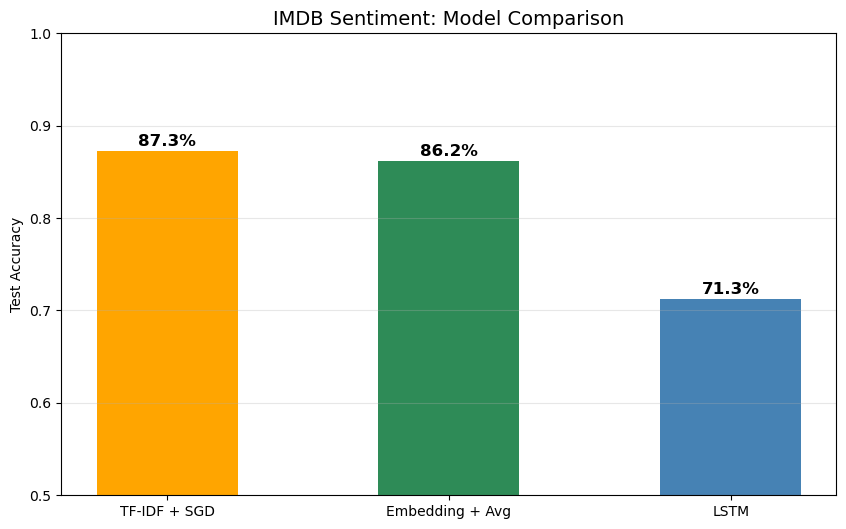

What this tells us:
- TF-IDF is fast and simple but limited
- Embeddings let the model learn word meanings
- LSTMs understand word order (the big leap!)


In [22]:
# Final comparison
models = ['TF-IDF + SGD', 'Embedding + Avg', 'LSTM']
accuracies = [
    accuracy_score(test_labels, test_preds),
    test_accuracies[-1],
    lstm_test_accuracies[-1]
]

colors = ['orange', 'seagreen', 'steelblue']
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.ylabel('Test Accuracy')
plt.ylim(0.5, 1.0)
plt.title('IMDB Sentiment: Model Comparison', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.1%}', ha='center', fontsize=12, fontweight='bold')

plt.show()

print("What this tells us:")
print("- TF-IDF is fast and simple but limited")
print("- Embeddings let the model learn word meanings")
print("- LSTMs understand word order (the big leap!)")

## Let's Test It on Our Own Reviews

Write any review and see how all three models predict it!

In [23]:
def predict_review(review_text, models_dict, vectorizer, word_to_id, max_len=200):
    """Predict sentiment of a custom review using all trained models."""
    print(f"Review: {review_text[:200]}..." if len(review_text) > 200 else f"Review: {review_text}")
    print()
    
    # TF-IDF prediction
    tfidf_vec = vectorizer.transform([review_text])
    tfidf_pred = models_dict['tfidf'].predict(tfidf_vec)[0]
    tfidf_prob = models_dict['tfidf'].predict_proba(tfidf_vec)[0][1]
    print(f"TF-IDF + SGD:     {'POSITIVE' if tfidf_pred == 1 else 'NEGATIVE'} (confidence: {tfidf_prob:.1%})")
    
    # Embedding model prediction
    tokens = clean_text(review_text)
    ids = encode_review(tokens, word_to_id, max_len)
    ids_tensor = torch.tensor([ids], dtype=torch.long).to(device)
    
    emb_model = models_dict['embedding']
    emb_model.eval()
    with torch.no_grad():
        emb_output = emb_model(ids_tensor)
        emb_prob = torch.sigmoid(emb_output).item()
    print(f"Embedding + Avg:  {'POSITIVE' if emb_prob > 0.5 else 'NEGATIVE'} (confidence: {emb_prob:.1%})")
    
    # LSTM prediction
    lstm_model = models_dict['lstm']
    lstm_model.eval()
    with torch.no_grad():
        lstm_output = lstm_model(ids_tensor)
        lstm_prob = torch.sigmoid(lstm_output).item()
    print(f"LSTM:             {'POSITIVE' if lstm_prob > 0.5 else 'NEGATIVE'} (confidence: {lstm_prob:.1%})")

# Package all models for prediction
models_dict = {
    'tfidf': bow_model,
    'embedding': emb_model,
    'lstm': lstm_model
}

print("=" * 60)
print("TESTING WITH EXAMPLE REVIEWS")
print("=" * 60)
print()

# Test some custom reviews
test_reviews = [
    "This movie was absolutely fantastic! The acting was brilliant and the story kept me hooked from start to finish. I highly recommend it.",
    "Worst film I've ever seen. The plot made no sense, the acting was terrible, and I fell asleep halfway through. Complete waste of time.",
    "The cinematography was beautiful and the actors gave it their all, but the script was boring and predictable.",
    "I don't know why people hate this movie. It wasn't bad at all. Sure it's not perfect, but it was definitely entertaining.",
]

for i, review in enumerate(test_reviews):
    print(f"\n{'='*60}")
    predict_review(review, models_dict, vectorizer, word_to_id)
    
print()
print("\n" + "=" * 60)
print("Can you write a review that confuses the models?")
print("Try one with mixed opinions or sarcasm!")

TESTING WITH EXAMPLE REVIEWS


Review: This movie was absolutely fantastic! The acting was brilliant and the story kept me hooked from start to finish. I highly recommend it.

TF-IDF + SGD:     POSITIVE (confidence: 93.0%)
Embedding + Avg:  POSITIVE (confidence: 90.3%)
LSTM:             NEGATIVE (confidence: 24.4%)

Review: Worst film I've ever seen. The plot made no sense, the acting was terrible, and I fell asleep halfway through. Complete waste of time.

TF-IDF + SGD:     NEGATIVE (confidence: 0.7%)
Embedding + Avg:  NEGATIVE (confidence: 0.9%)
LSTM:             NEGATIVE (confidence: 24.4%)

Review: The cinematography was beautiful and the actors gave it their all, but the script was boring and predictable.

TF-IDF + SGD:     NEGATIVE (confidence: 6.5%)
Embedding + Avg:  NEGATIVE (confidence: 16.2%)
LSTM:             NEGATIVE (confidence: 24.4%)

Review: I don't know why people hate this movie. It wasn't bad at all. Sure it's not perfect, but it was definitely entertaining.

TF-IDF 

## What You Built

1. **Loaded 50,000 IMDB reviews** — the standard benchmark for sentiment analysis
2. **TF-IDF with SGD Classifier** — a simple but effective baseline (~85%)
3. **Learned word embeddings** — a neural network that learns word meanings
4. **LSTM for sequence modeling** — reading words in order for better understanding

## Key Concepts

| Concept | Meaning |
|---------|---------|
| Tokenization | Splitting text into words |
| Vocabulary | Assigning each word a unique ID |
| TF-IDF | Scoring words by importance across documents |
| Embedding | A learnable vector that represents a word's meaning |
| Padding | Making all reviews the same length by adding zeros |
| LSTM | A neural network that reads words in sequence with memory |

## Things to Try

1. **Increase MAX_VOCAB** — does keeping more rare words help?
2. **Use pre-trained GloVe embeddings** — instead of learning from scratch, use word vectors trained on billions of words
3. **Bi-directional LSTM** — read words left-to-right AND right-to-left (context from both sides)
4. **Add more LSTM layers** — stack 2-3 LSTMs for deeper understanding
5. **Try a Transformer** — implement multi-head attention (the architecture behind GPT)

---
## Bonus: Visualize Word Embeddings

Let's actually *see* what the embedding layer learned. We'll find similar words and reduce them to 2D for visualization.

In [ ]:
from sklearn.decomposition import PCA

# Get the embedding weights from our trained model
embedding_weights = emb_model.embedding.weight.data.cpu().numpy()

# Find the nearest neighbors of some interesting words
def find_similar_words(word, word_to_id, embeddings, n=5):
    """Find the most similar words by cosine distance in embedding space."""
    if word not in word_to_id:
        print(f"'{word}' not in vocabulary")
        return
    
    word_id = word_to_id[word]
    word_vec = embeddings[word_id]
    
    # Compute cosine similarity with all words
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / (norms + 1e-8)
    similarities = normalized @ normalized[word_id]
    
    # Get top N most similar (excluding the word itself)
    most_similar = np.argsort(similarities)[-n-1:-1][::-1]
    
    # Reverse mapping: ID -> word
    id_to_word = {v: k for k, v in word_to_id.items()}
    
    print(f"Words most similar to '{word}':")
    for sim_id in most_similar:
        sim_word = id_to_word.get(sim_id, '<UNK>')
        print(f"  {sim_word:<15} similarity: {similarities[sim_id]:.3f}")

find_similar_words('good', word_to_id, embedding_weights)
print()
find_similar_words('bad', word_to_id, embedding_weights)
print()
find_similar_words('boring', word_to_id, embedding_weights)

In [ ]:
# Visualize embeddings in 2D using PCA
selected_words = [
    'good', 'great', 'amazing', 'excellent', 'wonderful', 'fantastic',
    'bad', 'terrible', 'awful', 'horrible', 'boring', 'worst',
    'movie', 'film', 'story', 'acting', 'plot', 'script'
]

# Get their vectors
selected_ids = []
selected_labels = []
for word in selected_words:
    if word in word_to_id:
        selected_ids.append(word_to_id[word])
        selected_labels.append(word)

vectors = embedding_weights[selected_ids]

# Reduce to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(10, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='steelblue', s=100)
for i, word in enumerate(selected_labels):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), 
                 fontsize=12, ha='center', va='bottom',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))
plt.title('Word Embeddings Visualized in 2D', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

print("Notice how positive words cluster together and negative words cluster together!")
print("The model learned that 'good' and 'great' are similar, "
      "while 'bad' and 'terrible' are also similar but far from positive words.")